In [1]:
!pip install selectivesearch
!pip install torch_snippets

In [5]:
from torch_snippets import *
import selectivesearch
from skimage.segmentation import felzenszwalb
import cv2
import matplotlib.pyplot as plt
import numpy as np

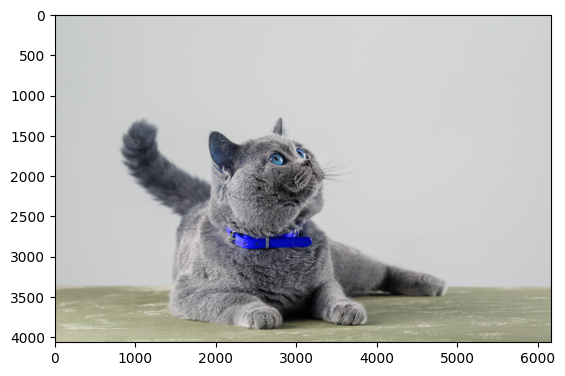

In [4]:
image = cv2.imread("/content/grey-cat-lying-looking-up.jpg")
plt.imshow(image)

In [8]:
def extract_candidates(image):
  image_label, regions = selectivesearch.selective_search(image, scale=200, min_size=100)
  image_area = np.prod(image.shape[:2])
  candidates = []
  for r in regions:
    if r['rect'] in candidates: continue
    if r['size'] < (0.05 * image_area) : continue
    if r['size'] > (1 * image_area) : continue

    x, y, w, h = r['rect']
    candidates.append(list(r['rect']))
    return candidates

In [ ]:
candidates = extract_candidates(image)

In [ ]:
show(image, bbs=candidates)